In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\ashis\Downloads\cleaned_train.xls")

In [4]:
df.head()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,loan_id,gender,married,dependents,education,self_employed,property_area,loan_status
0,6250.0,0.0,128.0,360.0,1.0,LP001750,Male,Yes,0,Graduate,No,Semiurban,Y
1,3250.0,0.0,170.0,360.0,1.0,LP001751,Male,Yes,0,Graduate,No,Rural,N
2,6250.0,1695.0,210.0,360.0,1.0,LP001758,Male,Yes,2,Graduate,No,Semiurban,Y
3,6400.0,0.0,200.0,360.0,1.0,LP001761,Male,No,0,Graduate,Yes,Rural,Y
4,2491.0,2054.0,104.0,360.0,1.0,LP001765,Male,Yes,1,Graduate,No,Semiurban,Y


In [5]:
len(df)

410

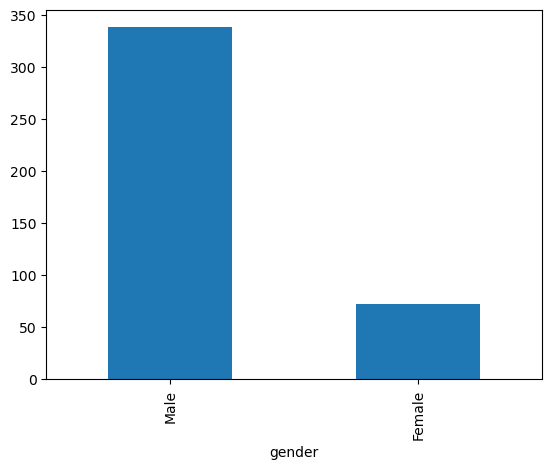

In [10]:
df['gender'].value_counts().plot(kind='bar')
plt.show()

## As per the above chart, there is a huge difference between male and female loan applicant where majority applicants are male.

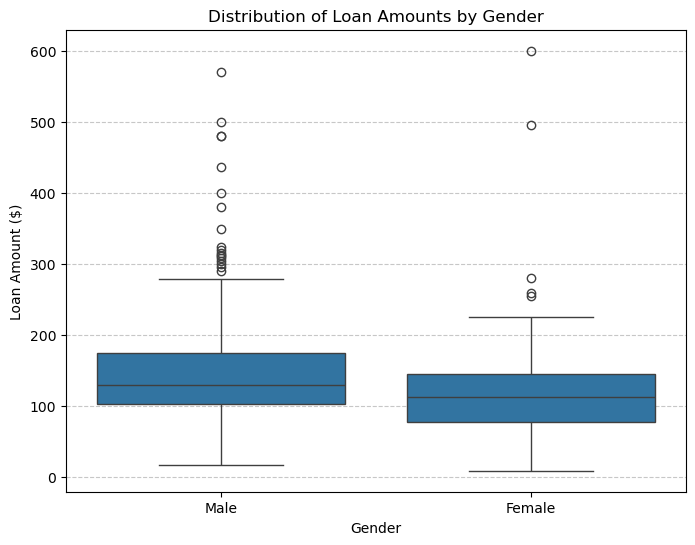

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='loanamount', data=df)
plt.title('Distribution of Loan Amounts by Gender')
plt.xlabel('Gender')
plt.ylabel('Loan Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## This is clear that the range of loans is slightly higher for males compared to females. Male loan amount are highre even beyond the range.

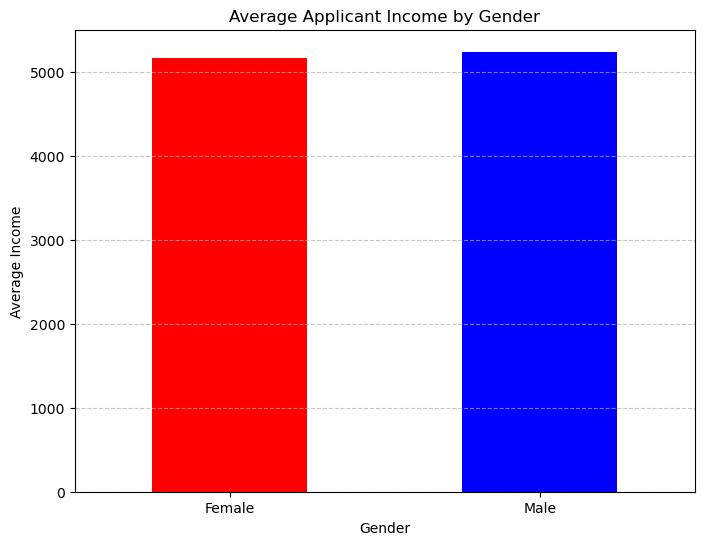

In [32]:
average_income = df.groupby('gender')['applicantincome'].mean()

plt.figure(figsize=(8, 6))
average_income.plot(kind='bar', color=['red', 'blue'])
plt.title('Average Applicant Income by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Income')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
average_income

gender
Female    5174.875000
Male      5245.204142
Name: applicantincome, dtype: float64

## The above plot shows that average income of male and female applicant is almost the same.

In [22]:
total_applicants = df['gender'].value_counts()

In [24]:
coapplicant_count = df[df['coapplicantincome'] == 'Yes']['gender'].value_counts()

In [25]:
percentage_with_coapplicant = (coapplicant_count / total_applicants) * 100

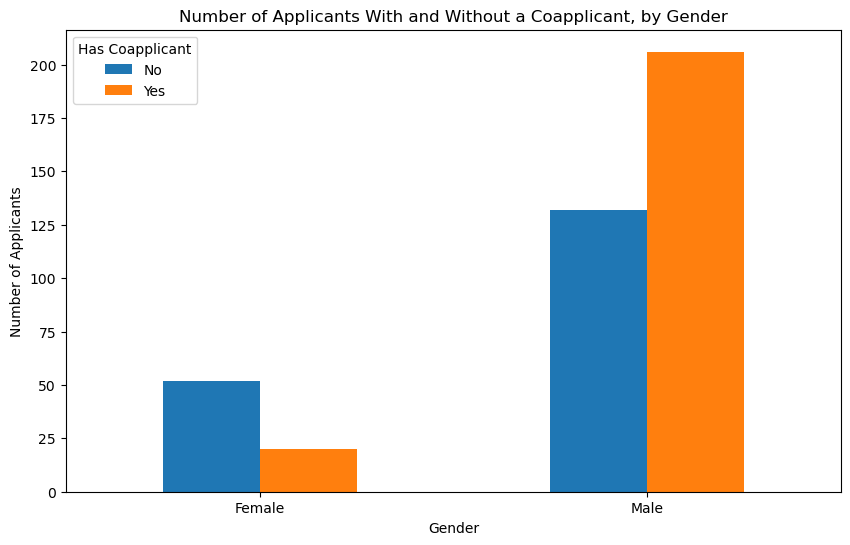

In [30]:
df['has_coapplicant'] = df['coapplicantincome'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Count the number of applicants for each gender and coapplicant status by yes or no
counts = df.groupby(['gender', 'has_coapplicant']).size().unstack(fill_value=0)

# Plotting the grouped bar chart
counts.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Applicants With and Without a Coapplicant, by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Has Coapplicant', loc='upper left')
plt.show()

## There is a huge difference in male and female applicant having coapplicants as per the above bar plot.
### Most of the male applicants are having co-applicants

In [33]:
# Creating a cross-tabulation table to count loan status by gender
loan_status_by_gender = pd.crosstab(df['gender'], df['loan_status'])

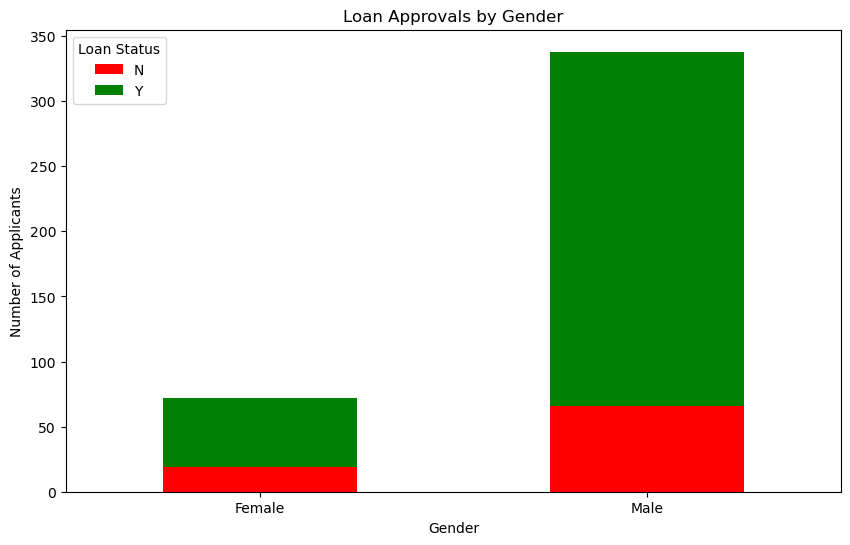

In [36]:
loan_status_by_gender.plot(kind='bar', stacked=True, figsize=(10, 6), color=['Red', 'Green'])
plt.title('Loan Approvals by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.show()

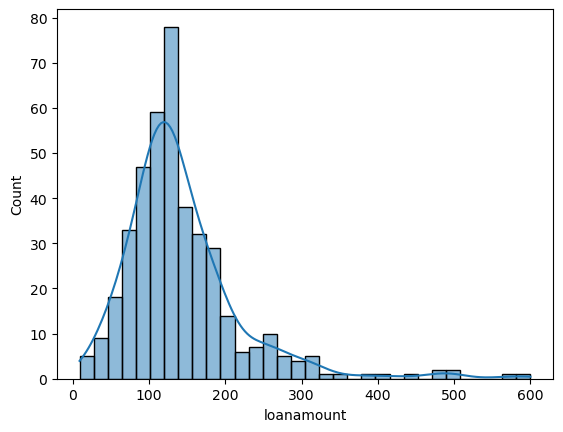

In [37]:
sns.histplot(data=df,x='loanamount',kde=True)
plt.show()

## The above plot shows the Kernel Density Estimate which shows the loan amount column has a bit skewed data.

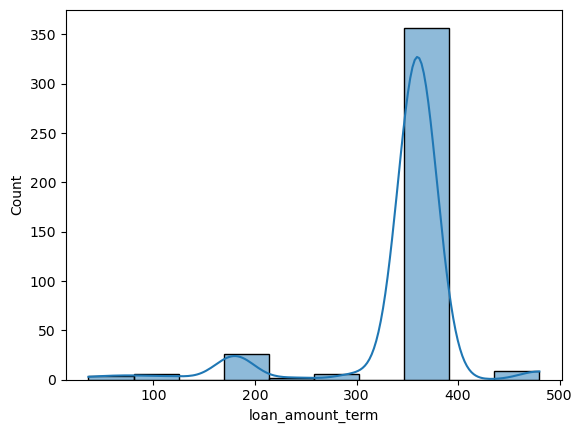

In [39]:
sns.histplot(data=df,x='loan_amount_term',kde=True)
plt.show()

## The above plot shows the Kernel Density Estimate which shows the loan term column also has a bit skewed data.

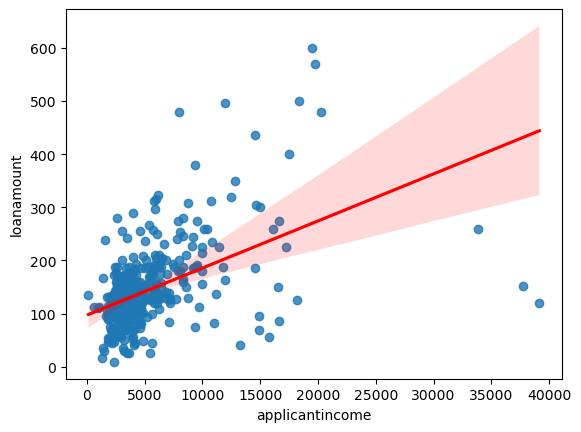

In [49]:
sns.regplot(data=df,x='applicantincome',y='loanamount', line_kws={"color":"red"})
plt.show()

## The above scatter plot shows the correlation between the applicant income and loan amount. Higher the income, higher the loan amount.
#### However, as per the data, most of the applicants has income below 10000 and loan amount below 300.
#### It still has slight positive correlation based on the data available.

## Multivariate Analysis for Continuous Data

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   applicantincome    410 non-null    float64
 1   coapplicantincome  410 non-null    float64
 2   loanamount         410 non-null    float64
 3   loan_amount_term   410 non-null    float64
 4   credit_history     410 non-null    float64
 5   loan_id            410 non-null    object 
 6   gender             410 non-null    object 
 7   married            410 non-null    object 
 8   dependents         410 non-null    object 
 9   education          410 non-null    object 
 10  self_employed      410 non-null    object 
 11  property_area      410 non-null    object 
 12  loan_status        410 non-null    object 
 13  has_coapplicant    410 non-null    object 
dtypes: float64(5), object(9)
memory usage: 45.0+ KB


In [53]:
con = list(df.columns[df.dtypes !="object"])
con

['applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history']

In [57]:
cat = list(df.columns[df.dtypes =="object"])
cat

['loan_id',
 'gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'property_area',
 'loan_status',
 'has_coapplicant']

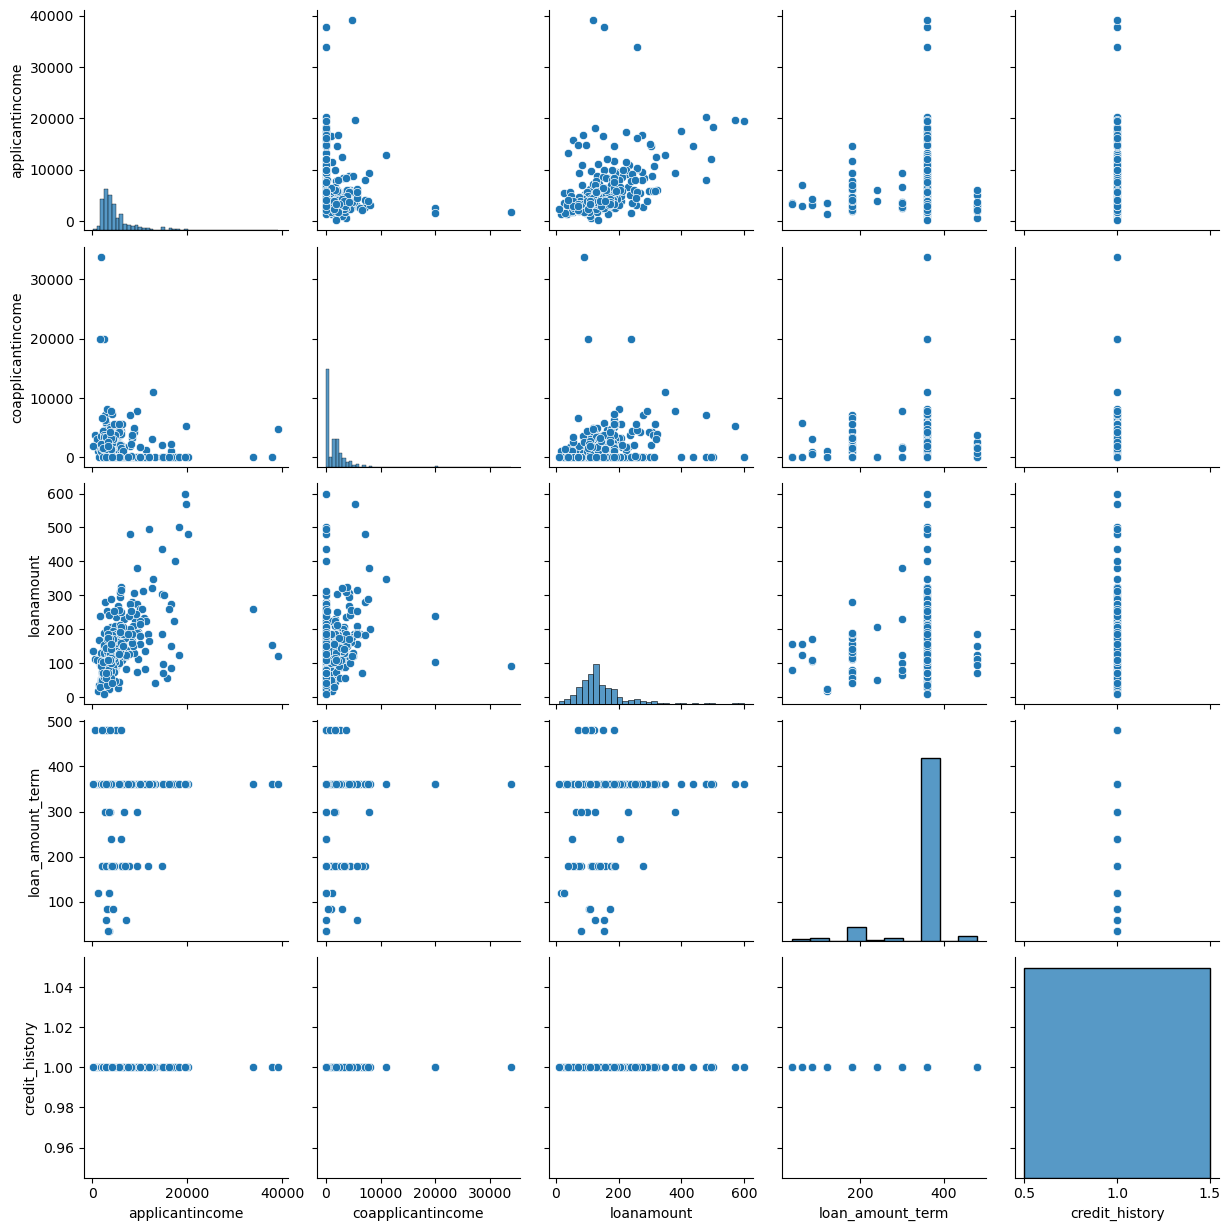

In [58]:
sns.pairplot(df[con])
plt.show()

## Observations:
#### Income and loan amount has a correlation where both increases proportionately.
#### There is a huge gap in terms of gender loan approvals. 
#### Most of the loan applicants choose highre loan term regardless of loan amount. 
#### Coaplicant income does not make much of a difference in loan amount. 

## Recommendations:
#### Business should consider focusing on increasing female loan applicants
#### Number of loans can be increased by providing separate loans to males and females instead of having them as coapplicant. 
#### Separating loans would also have an impact on loan amount which in turn increase loan revenue. 